# Localization controls and robustness

Tests whether the localizer uses meaningful coordinate–error associations and whether outcomes depend on one split or parameter.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## A different permutation from Notebook 05

Here the entire four-coordinate biological vector is shuffled between molecules independently within calibration and test. Point predictions and residuals stay fixed. Five coordinate permutations per partition are compared with the true coordinates. This tests interval localization, not predictor feature importance.

In [2]:
controls=table('localization_controls/metrics.csv');display(controls.groupby('method')[['coverage','mean_width','mean_interval_score']].mean())
paired=table('localization_controls/paired_scores.csv');display(paired.groupby('comparator').joint_minus_comparator_score.agg(['mean','min','max']))

,coverage,mean_width,mean_interval_score
method,,,
MW_logP,0.88906,1.50351,2.42926
permuted_biology_0,0.89794,1.59815,2.48015
permuted_biology_1,0.89892,1.60080,2.48651
permuted_biology_2,0.89915,1.60538,2.48296
permuted_biology_3,0.89950,1.60322,2.47902
permuted_biology_4,0.90039,1.61046,2.48236
prediction_only,0.89439,1.54755,2.44714


,mean,min,max
comparator,,,
MW_logP,-0.03184,-0.06945,0.02587
permuted_biology_0,-0.08274,-0.12358,-0.04841
permuted_biology_1,-0.08910,-0.12228,-0.05088
permuted_biology_2,-0.08554,-0.12522,-0.04837
permuted_biology_3,-0.08161,-0.11554,-0.04562
permuted_biology_4,-0.08495,-0.12122,-0.04679
prediction_only,-0.04972,-0.07587,-0.01262


In [3]:
d=dataset();cfg=read_json(RESULTS/'runs/butina04_seed42/complete.json')
p=table('runs/butina04_seed42/test_predictions.csv');cal=table('runs/butina04_seed42/calibration_predictions.csv')
raw=np.column_stack([d[PROTEINS].mean(axis=1),d[cfg['selected_markers']]])
z=pd.DataFrame((raw-np.array(cfg['coordinate_mu']))/np.array(cfg['coordinate_sd']),index=d.index)
zte=z.loc[p.ligand_id].to_numpy();zca=z.loc[cal.ligand_id].to_numpy();rng=np.random.default_rng(1000)
w,ne=local_intervals(zte[rng.permutation(len(zte))],zca[rng.permutation(len(zca))],cal.abs_residual.to_numpy(),cfg['global_quantile'])
expected=table('localization_controls/butina04_seed42_predictions.csv').width_permuted_biology_0
assert np.allclose(w,expected)
print('First shuffled-coordinate experiment reproduced.')

First shuffled-coordinate experiment reproduced.


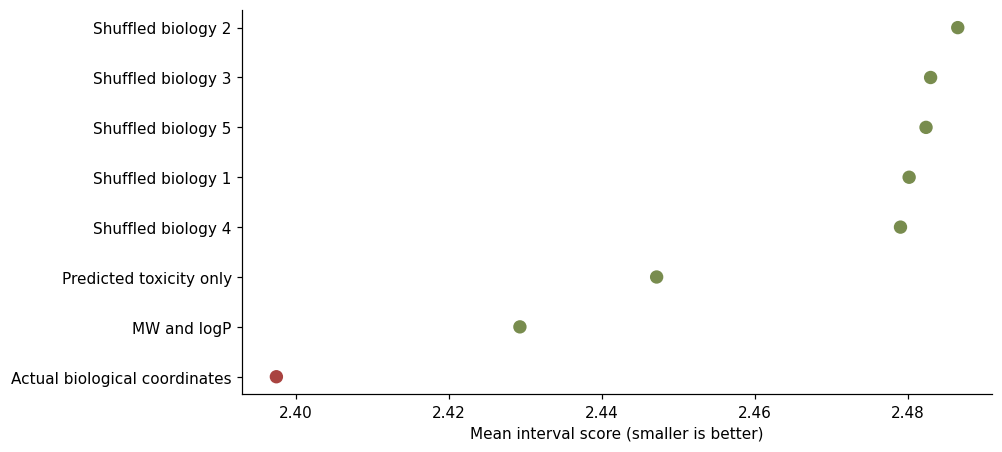

In [4]:
means=controls.groupby('method').mean_interval_score.mean()
overview=table('overview.csv')
means.loc['joint_real_biology']=overview[overview.run.str.match(r'butina04_seed4[2-6]$')].joint_score.mean()
means=means.sort_values()
labels=[('Shuffled biology '+str(int(k.rsplit('_',1)[1])+1)) if k.startswith('permuted_biology_') else {'joint_real_biology':'Actual biological coordinates','prediction_only':'Predicted toxicity only','MW_logP':'MW and logP'}.get(k,k) for k in means.index]
fig,ax=plt.subplots(figsize=(9,4),layout='constrained')
ax.scatter(means,range(len(means)),color=['#a94340' if k=='joint_real_biology' else '#788c4e' for k in means.index],s=60)
ax.set(yticks=range(len(means)),yticklabels=labels,xlabel='Mean interval score (smaller is better)')
finish(fig,'localization_controls')

## Cutoff, bandwidth, fallback and exact-identity sensitivity

Sensitivity outcomes are reported without selecting the best setting on test. Molecular-random controls match sample counts, but their test compounds differ from the structural tests, so their RMSE difference is not an isolated leakage estimate.

In [5]:
display(table('overview.csv'))
fallback=additional('fallback_sensitivity');display(fallback.groupby('minimum_neff')[['fallback_fraction','coverage','mean_width','interval_score']].mean())
strict=pd.read_csv(RESULTS/'strict_identity/overview.csv');display(strict)

,run,rmse,mae,r2,spearman,train,calibration,test,global_coverage,global_width,global_score,joint_coverage,joint_width,joint_score
0,butina03_seed42,0.49979,0.34687,0.50700,0.70899,8044,1933,2607,0.91063,1.56703,2.37727,0.90257,1.48820,2.29521
1,butina04_seed42,0.51655,0.36529,0.46250,0.66896,7910,2142,2532,0.90403,1.65259,2.41684,0.89415,1.52865,2.30956
2,butina04_seed43,0.52544,0.36271,0.44170,0.67155,8120,2005,2459,0.88695,1.52427,2.47409,0.89386,1.46023,2.39295
3,butina04_seed44,0.52572,0.36313,0.45131,0.66414,8021,2176,2387,0.91579,1.75460,2.52189,0.91412,1.66428,2.40365
4,butina04_seed45,0.54209,0.36475,0.46951,0.69274,8005,2025,2554,0.88880,1.51778,2.56257,0.87471,1.42596,2.51473
5,butina04_seed46,0.50683,0.35182,0.47311,0.67343,8129,1905,2550,0.89804,1.57901,2.41464,0.89176,1.50194,2.36619
6,butina05_seed42,0.52122,0.35896,0.41163,0.63025,8009,1903,2672,0.91018,1.62226,2.47146,0.89933,1.51483,2.37649
7,random_size_matched_seed42,0.49218,0.33945,0.52199,0.71652,7910,2142,2532,0.90047,1.44729,2.28951,0.89850,1.39035,2.20938
8,random_size_matched_seed43,0.48169,0.34114,0.55670,0.72754,8120,2005,2459,0.90118,1.46968,2.26081,0.89793,1.40864,2.18660
9,random_size_matched_seed44,0.49599,0.34790,0.52933,0.72748,8021,2176,2387,0.90616,1.52468,2.30346,0.90239,1.44450,2.22132


,fallback_fraction,coverage,mean_width,interval_score
minimum_neff,,,,
40,0.00826,0.89420,1.51980,2.39595
80,0.01387,0.89372,1.51621,2.39742
120,0.02632,0.89284,1.51118,2.39989


,run,rmse,mae,r2,spearman,calibration,test,train,global_coverage,global_width,global_score,joint_coverage,joint_width,joint_score
0,butina04_seed42,0.51772,0.36716,0.44433,0.65855,2081,2464,7648,0.91112,1.68723,2.41480,0.89205,1.52710,2.29052
1,butina04_seed43,0.52192,0.36173,0.43051,0.66840,1957,2392,7844,0.88921,1.53249,2.45001,0.89089,1.46346,2.36375
2,butina04_seed44,0.52967,0.36373,0.43098,0.65275,2112,2332,7749,0.92110,1.79839,2.55754,0.91552,1.67398,2.43385
3,butina04_seed45,0.54636,0.36886,0.45239,0.68174,1953,2500,7740,0.89160,1.54513,2.56911,0.87640,1.45695,2.51708
4,butina04_seed46,0.50978,0.35543,0.46040,0.65778,1849,2494,7850,0.90016,1.59856,2.42011,0.89294,1.50196,2.36309


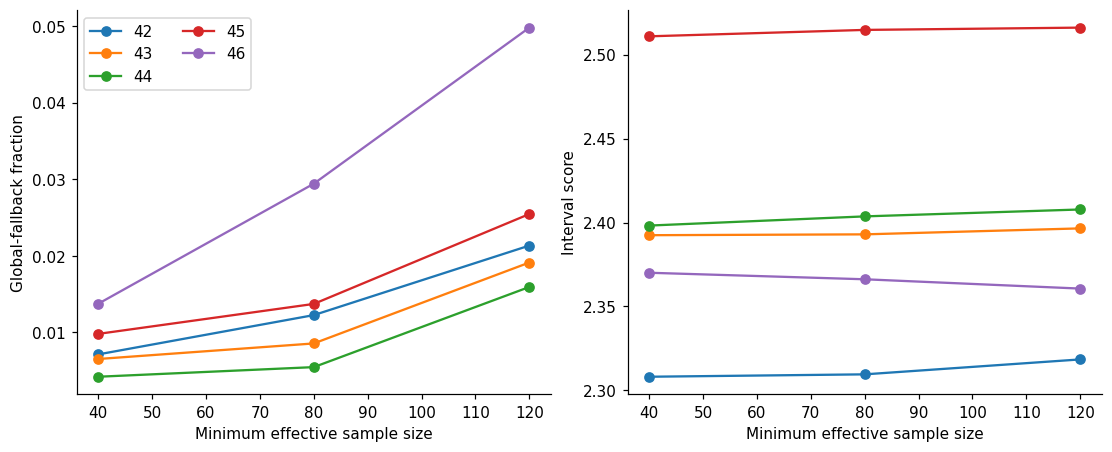

In [6]:
fig,axs=plt.subplots(1,2,figsize=(10,4),layout='constrained')
for seed,g in fallback.groupby('seed'):
    axs[0].plot(g.minimum_neff,g.fallback_fraction,'o-',label=str(seed))
    axs[1].plot(g.minimum_neff,g.interval_score,'o-')
axs[0].set(xlabel='Minimum effective sample size',ylabel='Global-fallback fraction');axs[1].set(xlabel='Minimum effective sample size',ylabel='Interval score');axs[0].legend(ncol=2);finish(fig,'fallback_sensitivity')